# Employee Turnover Prediction - Salifort Motors

        Course capstone project using a simulated HR dataset.

        This notebook analyzes employee survey and workplace data to understand patterns associated with turnover and compare models that predict whether an employee left the organization.


## Business Problem

        Employee turnover can create operational disruption and hiring costs. The goal of this project is to identify employee characteristics associated with turnover and build classification models that predict the target variable `left`.

        - `0` = employee stayed
        - `1` = employee left


## Imports


In [1]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    confusion_matrix,

    ConfusionMatrixDisplay,

    classification_report,

    RocCurveDisplay

)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Import XGBoost

from xgboost import XGBClassifier


## Dataset Overview

        The dataset contains simulated HR records from the Google Advanced Data Analytics capstone project. It includes satisfaction, evaluation score, project count, monthly hours, tenure, work accident history, promotion history, department, salary, and turnover status.


In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset
df0 = pd.read_csv("../data/HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
# Gather descriptive statistics about the data
df0.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## Data Cleaning

        Column names are standardized for readability. The analysis also checks for missing values, duplicate rows, and tenure outliers.


In [5]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df = df0.rename(columns={
    'satisfaction_level': 'satisfaction',
    'last_evaluation': 'last_evaluation',
    'number_project': 'project_count',
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'tenure_years',
    'Work_accident': 'work_accident',
    'left': 'left',
    'promotion_last_5years': 'promotion_last_5_years',
    'Department': 'department',
    'salary': 'salary'
})

# Confirm the updated column names
df.columns


Index(['satisfaction', 'last_evaluation', 'project_count',
       'average_monthly_hours', 'tenure_years', 'work_accident', 'left',
       'promotion_last_5_years', 'department', 'salary'],
      dtype='object')

In [7]:
# Check for missing values
# Check for missing values in each column
missing_values = df.isna().sum()
missing_values


satisfaction              0
last_evaluation           0
project_count             0
average_monthly_hours     0
tenure_years              0
work_accident             0
left                      0
promotion_last_5_years    0
department                0
salary                    0
dtype: int64

In [8]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
duplicate_count


3008

In [9]:
# Inspect some rows containing duplicates as needed
# Inspect some rows containing duplicates
df[df.duplicated()].head(10)


,satisfaction,last_evaluation,project_count,average_monthly_hours,tenure_years,work_accident,left,promotion_last_5_years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df_clean = df.drop_duplicates().reset_index(drop=True)

# Display first few rows of new dataframe as needed
df_clean.head(10)


,satisfaction,last_evaluation,project_count,average_monthly_hours,tenure_years,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


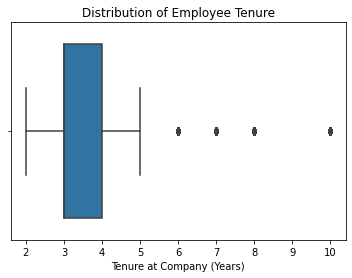

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers

plt.figure(figsize=(6, 4))
sns.boxplot(x=df_clean['tenure_years'])
plt.title('Distribution of Employee Tenure')
plt.xlabel('Tenure at Company (Years)')
plt.show()


In [12]:
# Determine the number of rows containing outliers

# Calculate Q1, Q3, and IQR
Q1 = df_clean['tenure_years'].quantile(0.25)
Q3 = df_clean['tenure_years'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Count rows with outliers
outliers = df_clean[
    (df_clean['tenure_years'] < lower_limit) |
    (df_clean['tenure_years'] > upper_limit)
]

len(outliers)


824

## Exploratory Data Analysis

        The EDA focuses on turnover patterns across satisfaction, workload, project count, tenure, salary, department, and promotion history. These patterns are interpreted as associations, not causal claims.


In [13]:
# Create summary table for people who left vs. stayed
turnover_summary = pd.DataFrame({
    'count': df_clean['left'].value_counts().sort_index(),
    'percentage': (df_clean['left'].value_counts(normalize=True).sort_index() * 100).round(2)
})

turnover_summary


,count,percentage
0,10000,83.4
1,1991,16.6


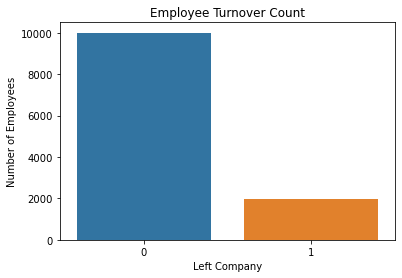

In [14]:
# Create a plot as needed
# Visualize how many employees left vs. stayed
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='left')
plt.title('Employee Turnover Count')
plt.xlabel('Left Company')
plt.ylabel('Number of Employees')
plt.show()


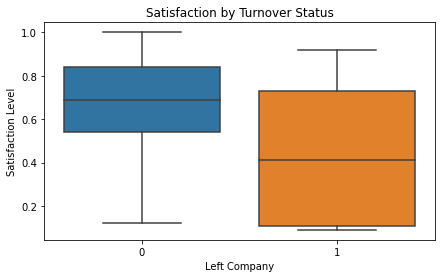

In [15]:
# Create a plot as needed
# Visualize satisfaction distribution by turnover status

plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x='left', y='satisfaction')

plt.title('Satisfaction by Turnover Status')

plt.xlabel('Left Company')

plt.ylabel('Satisfaction Level')

plt.show()


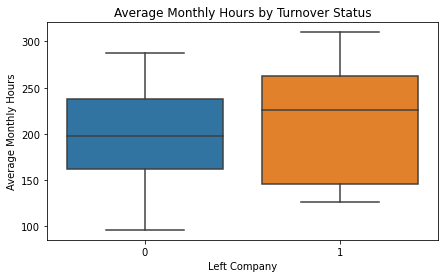

In [16]:
# Create a plot as needed
# Visualize average monthly hours by turnover status
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x='left', y='average_monthly_hours')
plt.title('Average Monthly Hours by Turnover Status')
plt.xlabel('Left Company')
plt.ylabel('Average Monthly Hours')
plt.show()


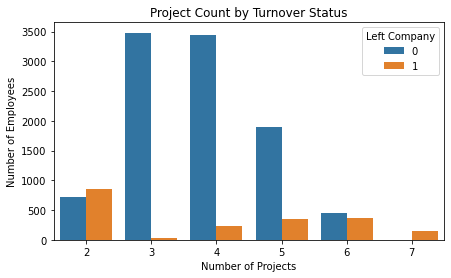

In [17]:
# Create a plot as needed
# Visualize project count by turnover status
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x='project_count', hue='left')
plt.title('Project Count by Turnover Status')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company')
plt.show()


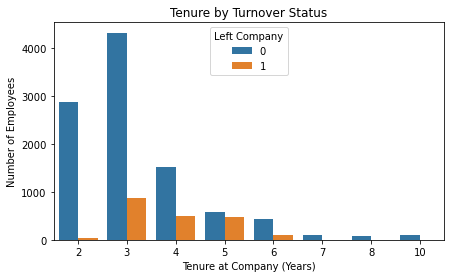

In [18]:
# Visualize tenure by turnover status
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x='tenure_years', hue='left')
plt.title('Tenure by Turnover Status')
plt.xlabel('Tenure at Company (Years)')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company')
plt.show()


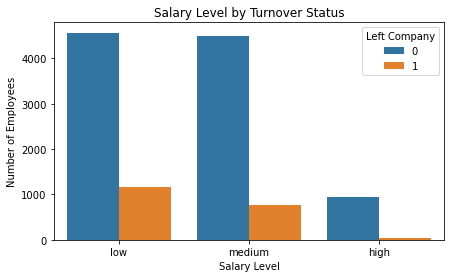

In [19]:
# Create a plot as needed
# Visualize salary level by turnover status
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x='salary', hue='left', order=['low', 'medium', 'high'])
plt.title('Salary Level by Turnover Status')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.legend(title='Left Company')
plt.show()


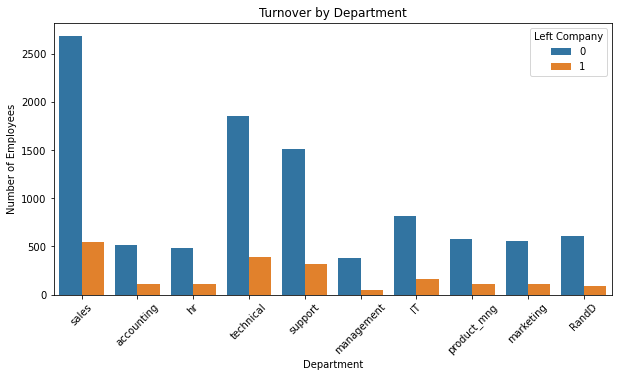

In [20]:
# Create a plot as needed
# Visualize department by turnover status
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='department', hue='left')
plt.title('Turnover by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.legend(title='Left Company')
plt.show()


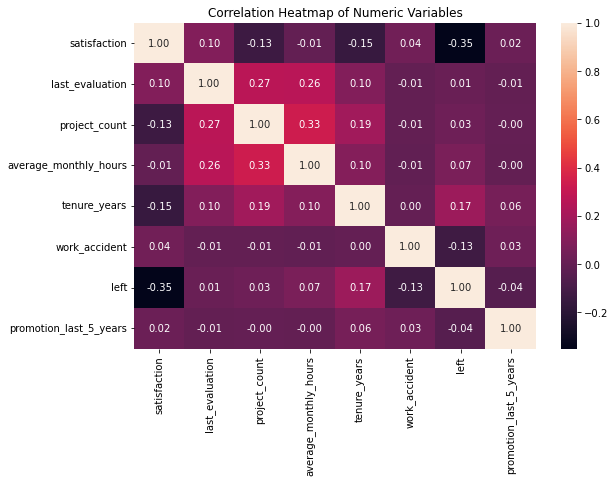

In [21]:
# Visualize correlations between numeric variables

# Select only numeric columns first
numeric_df = df_clean.select_dtypes(include='number')

plt.figure(figsize=(9, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


In [22]:
# Turnover rate by tenure
df_clean.groupby('tenure_years')['left'].mean().round(2)


tenure_years
2     0.01
3     0.17
4     0.25
5     0.45
6     0.20
7     0.00
8     0.00
10    0.00
Name: left, dtype: float64

In [23]:
# Turnover rate by project count
df_clean.groupby('project_count')['left'].mean().round(2)


project_count
2    0.54
3    0.01
4    0.06
5    0.15
6    0.45
7    1.00
Name: left, dtype: float64

In [24]:
# Turnover rate by department
df_clean.groupby('department')['left'].mean().sort_values(ascending=False).round(2)


department
hr             0.19
accounting     0.18
technical      0.17
support        0.17
sales          0.17
marketing      0.17
IT             0.16
product_mng    0.16
RandD          0.12
management     0.12
Name: left, dtype: float64

In [25]:
# Turnover rate by salary level
df_clean.groupby('salary')['left'].mean().sort_values(ascending=False).round(2)


salary
low       0.20
medium    0.15
high      0.05
Name: left, dtype: float64

In [26]:
# Compare average values for employees who stayed vs. left
df_clean.groupby('left')[[
    'satisfaction',
    'last_evaluation',
    'project_count',
    'average_monthly_hours',
    'tenure_years',
    'work_accident',
    'promotion_last_5_years'
]].mean().round(2)


,satisfaction,last_evaluation,project_count,average_monthly_hours,tenure_years,work_accident,promotion_last_5_years
left,,,,,,,
0,0.67,0.72,3.79,198.94,3.26,0.17,0.02
1,0.44,0.72,3.88,208.16,3.88,0.05,0.00


## EDA Summary

            Turnover is not evenly distributed across employee groups. Lower satisfaction, project count, monthly hours, tenure, salary, and promotion history all appear associated with turnover patterns in this simulated dataset.


## Model Building

            This is a supervised binary classification task. Logistic regression is used as an interpretable baseline. Decision tree, random forest, and XGBoost models are used to compare machine learning approaches.


In [27]:
# Define target variable
y = df_clean['left']

# Define predictor variables
X = df_clean.drop(columns=['left'])

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [28]:
# Scale features for logistic regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
# Build and fit logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [30]:
# Generate logistic regression predictions
log_reg_preds = log_reg.predict(X_test_scaled)
log_reg_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, log_reg_preds))


              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2500
           1       0.49      0.21      0.29       498

    accuracy                           0.83      2998
   macro avg       0.68      0.58      0.60      2998
weighted avg       0.80      0.83      0.80      2998



In [31]:
# Build and fit decision tree model
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)


DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=5, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=42, splitter='best')

In [32]:
# Generate decision tree predictions
tree_preds = tree.predict(X_test)
tree_probs = tree.predict_proba(X_test)[:, 1]

print(classification_report(y_test, tree_preds))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2500
           1       0.96      0.93      0.94       498

    accuracy                           0.98      2998
   macro avg       0.97      0.96      0.97      2998
weighted avg       0.98      0.98      0.98      2998



In [33]:
# Build and fit random forest model
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=8
)

rf.fit(X_train, y_train)


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=8, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [34]:
# Generate random forest predictions
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_preds))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2500
           1       0.99      0.92      0.95       498

    accuracy                           0.98      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.98      0.98      0.98      2998



In [35]:
# Build and fit XGBoost model
xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=4, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=0, num_parallel_tree=1,
              objective='binary:logistic', predictor='auto', random_state=42,
              reg_alpha=0, ...)

In [36]:
# Generate XGBoost predictions
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2500
           1       0.97      0.93      0.95       498

    accuracy                           0.98      2998
   macro avg       0.98      0.96      0.97      2998
weighted avg       0.98      0.98      0.98      2998



## Final Model Comparison

            The final comparison focuses on logistic regression, decision tree, and random forest results from the notebook. XGBoost was also run as a supplemental model, but random forest is selected because it provides the strongest balance of precision, recall, and F1-score for the leaver class in the main comparison table.


In [37]:
# Create model comparison table
results = pd.DataFrame({
    'model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'accuracy': [0.83, 0.98, 0.98],
    'precision_left': [0.49, 0.96, 0.99],
    'recall_left': [0.21, 0.93, 0.92],
    'f1_left': [0.29, 0.94, 0.95]
})

results


,model,accuracy,precision_left,recall_left,f1_left
0,Logistic Regression,0.83,0.49,0.21,0.29
1,Decision Tree,0.98,0.96,0.93,0.94
2,Random Forest,0.98,0.99,0.92,0.95


## Recommendations

            - Monitor broader employee groups with low satisfaction scores.
            - Review workload balance for employees with unusually high or low project counts.
            - Investigate turnover risk patterns around 4-6 years of tenure.
            - Review salary and promotion patterns.
            - Use model results as decision support for HR planning, not as automated decision-making.


## Ethics and Limitations

            The model should not be used to label individual employees as "flight risks," punish employees, or make automated employment decisions. It should be used to identify broader retention patterns and support HR decision-making.

            Limitations include the simulated/course-provided dataset, the lack of causal evidence, and missing context such as manager history, compensation changes, engagement comments, team size, and voluntary vs. involuntary turnover. Any model should be validated before real-world use.
